# Analyse de la robustesse du MLP2 face au bruit

## 1. Chargement des données et récupération du meilleur MLP2


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from mlp_model import train_mlp_2_hidden, predict_2_hidden
from linear_model import accuracy
from utils import one_hot_encode
from random_search_utils import load_results, save_results

In [2]:
# =========================
# Chargement et préparation MNIST
# =========================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisation
X_train = X_train.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

# Aplatissement
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

# One-hot encoding
Y_train = one_hot_encode(y_train, num_classes=10)
Y_test = one_hot_encode(y_test, num_classes=10)

print("X_train_flat :", X_train_flat.shape)
print("X_test_flat :", X_test_flat.shape)
print("Y_train :", Y_train.shape)
print("Y_test :", Y_test.shape)

X_train_flat : (60000, 784)
X_test_flat : (10000, 784)
Y_train : (60000, 10)
Y_test : (10000, 10)


In [4]:
# Rechargement du meilleur MLP2 entraine sur images propres


all_mlp2_results = []

try:
    data_night = load_results("all_mlp2_night_reasonable.pkl")
    all_mlp2_results += data_night["results_mlp2"]
except FileNotFoundError:
    print("Fichier all_mlp2_night_reasonable.pkl non trouvé.")

try:
    data_final = load_results("all_mlp2_final_search.pkl")
    all_mlp2_results += data_final["results_mlp2"]
except FileNotFoundError:
    print("Fichier all_mlp2_final_search.pkl non trouvé.")

try:
    data_high = load_results("results_mlp2_high_lr.pkl")

    if isinstance(data_high, list):
        all_mlp2_results += data_high
    elif isinstance(data_high, dict) and "results_mlp2" in data_high:
        all_mlp2_results += data_high["results_mlp2"]
    elif isinstance(data_high, dict) and "results" in data_high:
        all_mlp2_results += data_high["results"]

except FileNotFoundError:
    print("Fichier results_mlp2_high_lr.pkl non trouvé.")

best_mlp2_clean = max(all_mlp2_results, key=lambda r: r["valid_accuracy"])

print("Meilleur MLP2 propre :")
print("Validation accuracy :", best_mlp2_clean["valid_accuracy"])
print("Paramètres :", best_mlp2_clean["params"])

Meilleur MLP2 propre :
Validation accuracy : 0.956
Paramètres : {'hidden_dim1': 512, 'hidden_dim2': 128, 'learning_rate': 0.2, 'epochs': 350}


## 2. Ajout de bruit gaussien aux images

Pour tester la robustesse du modèle, nous ajoutons du bruit gaussien aux images. Plus la valeur de sigma est grande, plus le bruit ajouté est important. Les pixels sont ensuite limités entre 0 et 1 pour rester dans le même format que les images normalisées.

In [5]:
# Fonction de bruit gaussien

def add_gaussian_noise(X, sigma=0.1, seed=None):
    """
    Ajoute un bruit gaussien aux images.

    X : données normalisées entre 0 et 1
    sigma : intensité du bruit
    seed : graine pour rendre le bruit reproductible
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=sigma, size=X.shape)

    X_noisy = X + noise
    X_noisy = np.clip(X_noisy, 0.0, 1.0)

    return X_noisy

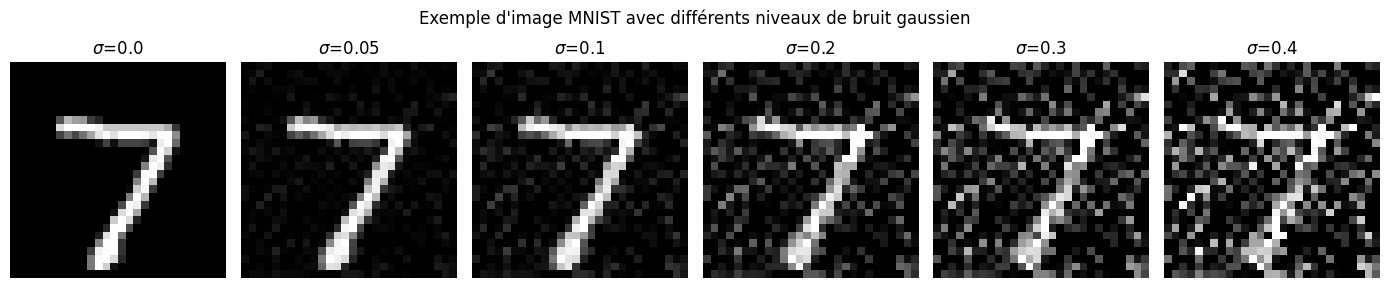

In [6]:
# Visualisation de différents niveaux de bruit


sigmas = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]
idx = 0

plt.figure(figsize=(14, 3))

for i, sigma in enumerate(sigmas):
    X_test_noisy = add_gaussian_noise(X_test, sigma=sigma, seed=42)

    plt.subplot(1, len(sigmas), i + 1)
    plt.imshow(X_test_noisy[idx], cmap="gray")
    plt.title(f"$\\sigma$={sigma}")
    plt.axis("off")

plt.suptitle("Exemple d'image MNIST avec différents niveaux de bruit gaussien")
plt.tight_layout()
plt.show()

## 3. Entraînement d'un MLP2 sur des images bruitées

Nous entraînons ensuite un nouveau MLP2 avec la même architecture que notre meilleur modèle, mais sur des images d'entraînement bruitées. Le but est de voir si le fait d'apprendre sur des images dégradées permet au modèle d'être plus robuste lors du test.

### A) Bruit Gaussien

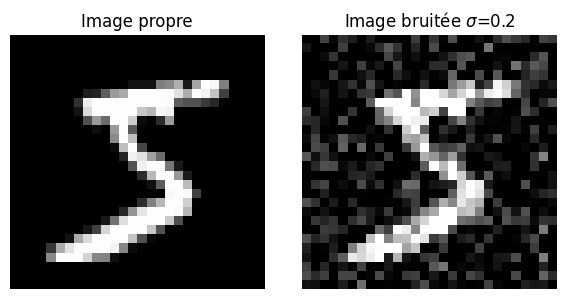

In [7]:
# Création du train set bruité

sigma_train = 0.2

X_train_noisy_flat = add_gaussian_noise(
    X_train_flat,
    sigma=sigma_train,
    seed=123
)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(X_train_flat[0].reshape(28, 28), cmap="gray")
plt.title("Image propre")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train_noisy_flat[0].reshape(28, 28), cmap="gray")
plt.title(f"Image bruitée $\\sigma$={sigma_train}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Entraînement du MLP2 sur images bruitées


A1_noisy, b1_noisy, A2_noisy, b2_noisy, A3_noisy, b3_noisy, loss_history_noisy = train_mlp_2_hidden(
    X_train_noisy_flat,
    Y_train,
    input_dim=784,
    hidden_dim1=512,
    hidden_dim2=128,
    num_classes=10,
    learning_rate=0.2,
    epochs=350
)

In [12]:
# Test du MLP2 entraîné sur images bruitées sur le test set propre


y_pred_noisy_clean = predict_2_hidden(
    X_test_flat,
    A1_noisy, b1_noisy,
    A2_noisy, b2_noisy,
    A3_noisy, b3_noisy
)

acc_noisy_clean = accuracy(y_test, y_pred_noisy_clean)

print("Accuracy du MLP2 entraîné sur bruit et testé sur images propres :", acc_noisy_clean)

Accuracy du MLP2 entraîné sur bruit et testé sur images propres : 0.9374


In [13]:
# Sauvegarde du MLP2 entraîné sur images bruitées


save_results("mlp2_trained_with_noise_sigma_02_h512_h128.pkl", {
    "sigma_train": sigma_train,
    "params": {
        "hidden_dim1": 512,
        "hidden_dim2": 128,
        "learning_rate": 0.2,
        "epochs": 350
    },
    "A1": A1_noisy,
    "b1": b1_noisy,
    "A2": A2_noisy,
    "b2": b2_noisy,
    "A3": A3_noisy,
    "b3": b3_noisy,
    "loss_history": loss_history_noisy,
    "accuracy_clean_test": acc_noisy_clean
})

In [14]:
# Comparaison sur plusieurs niveaux de bruit

params_clean = best_mlp2_clean["best_parameters"]

sigmas_test = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]

results_noise = []

for sigma in sigmas_test:
    X_test_noisy_flat = add_gaussian_noise(
        X_test_flat,
        sigma=sigma,
        seed=42
    )

    # Modèle entraîné sur images propres
    y_pred_clean = predict_2_hidden(
        X_test_noisy_flat,
        params_clean["A1"],
        params_clean["b1"],
        params_clean["A2"],
        params_clean["b2"],
        params_clean["A3"],
        params_clean["b3"]
    )

    acc_clean = accuracy(y_test, y_pred_clean)

    # Modèle entraîné sur images bruitées
    y_pred_noisy = predict_2_hidden(
        X_test_noisy_flat,
        A1_noisy, b1_noisy,
        A2_noisy, b2_noisy,
        A3_noisy, b3_noisy
    )

    acc_noisy = accuracy(y_test, y_pred_noisy)

    results_noise.append({
        "sigma": sigma,
        "MLP2 entraîné sur images propres": acc_clean,
        "MLP2 entraîné avec bruit": acc_noisy
    })

df_noise = pd.DataFrame(results_noise)
df_noise

,sigma,MLP2 entraîné sur images propres,MLP2 entraîné avec bruit
0,0.00,0.9516,0.9374
1,0.05,0.9498,0.9378
2,0.10,0.9442,0.9368
3,0.20,0.9173,0.9299
4,0.30,0.8185,0.9110
5,0.40,0.6759,0.8556


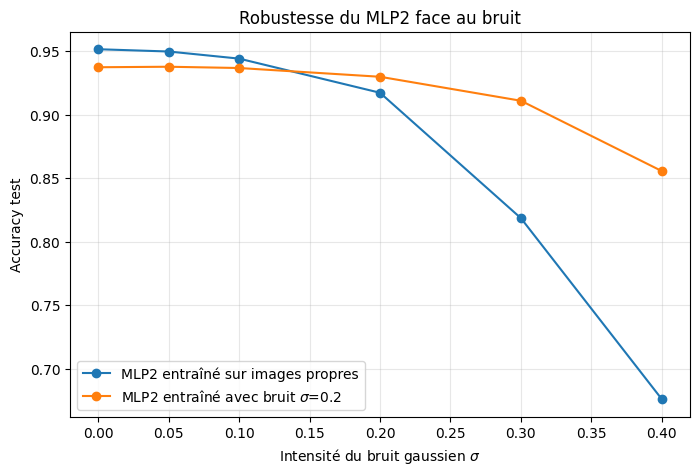

In [15]:
 # Graphique de robustesse face au bruit

plt.figure(figsize=(8, 5))

plt.plot(
    df_noise["sigma"],
    df_noise["MLP2 entraîné sur images propres"],
    marker="o",
    label="MLP2 entraîné sur images propres"
)

plt.plot(
    df_noise["sigma"],
    df_noise["MLP2 entraîné avec bruit"],
    marker="o",
    label=f"MLP2 entraîné avec bruit $\\sigma$={sigma_train}"
)

plt.xlabel("Intensité du bruit gaussien $\\sigma$")
plt.ylabel("Accuracy test")
plt.title("Robustesse du MLP2 face au bruit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### B) Bruit sel et poivre

In [23]:
# Fonction de bruit sel et poivre


def add_salt_and_pepper_noise(X, amount=0.1, seed=None):
    """
    Ajoute du bruit sel et poivre aux images.

    X : données normalisées entre 0 et 1
    amount : proportion de pixels modifiés
    seed : graine pour rendre le bruit reproductible
    """
    rng = np.random.default_rng(seed)

    X_noisy = X.copy()

    # Masque des pixels modifiés
    mask = rng.random(X.shape) < amount

    # Pour les pixels modifiés, moitié à 0 et moitié à 1
    salt_or_pepper = rng.random(X.shape) < 0.5

    X_noisy[mask & salt_or_pepper] = 1.0
    X_noisy[mask & ~salt_or_pepper] = 0.0

    return X_noisy

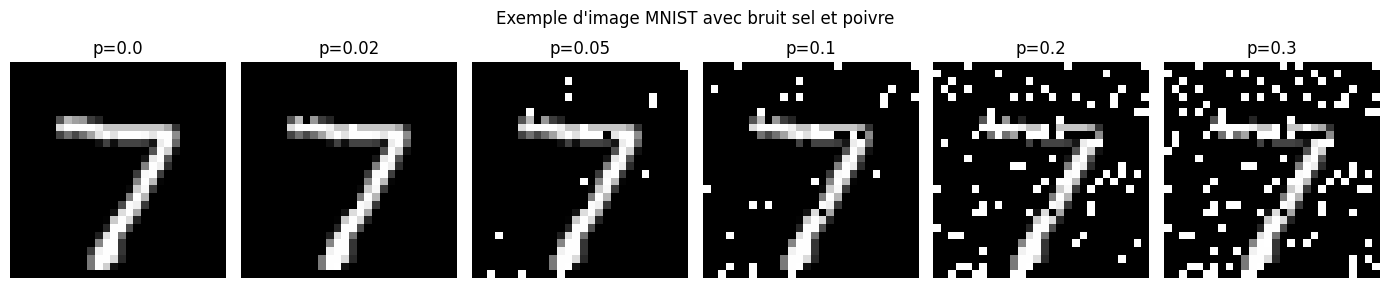

In [24]:
# Visualisation du bruit sel et poivre


amounts = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30]
idx = 0

plt.figure(figsize=(14, 3))

for i, amount in enumerate(amounts):
    X_test_sp = add_salt_and_pepper_noise(
        X_test,
        amount=amount,
        seed=42
    )

    plt.subplot(1, len(amounts), i + 1)
    plt.imshow(X_test_sp[idx], cmap="gray")
    plt.title(f"p={amount}")
    plt.axis("off")

plt.suptitle("Exemple d'image MNIST avec bruit sel et poivre")
plt.tight_layout()
plt.show()

In [25]:
# Comparaison sur bruit sel et poivre


params_clean = best_mlp2_clean["best_parameters"]

amounts_test = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30]

results_sp_noise = []

for amount in amounts_test:
    X_test_sp_flat = add_salt_and_pepper_noise(
        X_test_flat,
        amount=amount,
        seed=42
    )

    # Modèle entraîné sur images propres
    y_pred_clean_sp = predict_2_hidden(
        X_test_sp_flat,
        params_clean["A1"],
        params_clean["b1"],
        params_clean["A2"],
        params_clean["b2"],
        params_clean["A3"],
        params_clean["b3"]
    )

    acc_clean_sp = accuracy(y_test, y_pred_clean_sp)

    # Modèle entraîné avec bruit gaussien
    y_pred_noisy_sp = predict_2_hidden(
        X_test_sp_flat,
        A1_noisy, b1_noisy,
        A2_noisy, b2_noisy,
        A3_noisy, b3_noisy
    )

    acc_noisy_sp = accuracy(y_test, y_pred_noisy_sp)

    results_sp_noise.append({
        "proportion_pixels_modifies": amount,
        "MLP2 entraîné sur images propres": acc_clean_sp,
        "MLP2 entraîné avec bruit gaussien": acc_noisy_sp
    })

df_sp_noise = pd.DataFrame(results_sp_noise)
df_sp_noise

,proportion_pixels_modifies,MLP2 entraîné sur images propres,MLP2 entraîné avec bruit gaussien
0,0.00,0.9516,0.9374
1,0.02,0.9439,0.9344
2,0.05,0.9365,0.9300
3,0.10,0.9111,0.9186
4,0.20,0.7936,0.8778
5,0.30,0.6240,0.7907


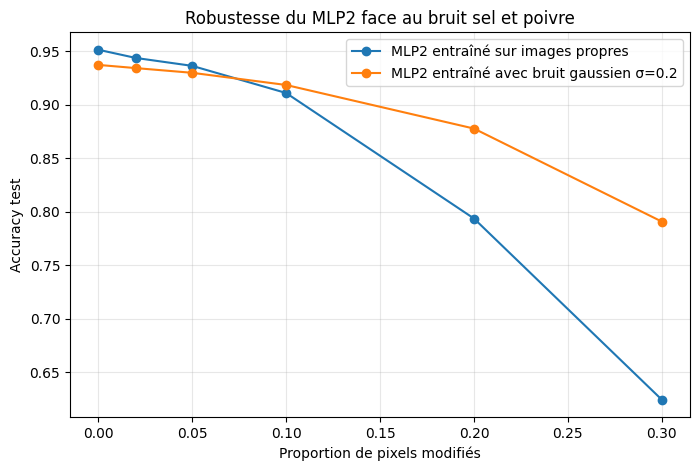

In [26]:
# Graphique robustesse face au bruit sel et poivre


plt.figure(figsize=(8, 5))

plt.plot(
    df_sp_noise["proportion_pixels_modifies"],
    df_sp_noise["MLP2 entraîné sur images propres"],
    marker="o",
    label="MLP2 entraîné sur images propres"
)

plt.plot(
    df_sp_noise["proportion_pixels_modifies"],
    df_sp_noise["MLP2 entraîné avec bruit gaussien"],
    marker="o",
    label=f"MLP2 entraîné avec bruit gaussien σ={sigma_train}"
)

plt.xlabel("Proportion de pixels modifiés")
plt.ylabel("Accuracy test")
plt.title("Robustesse du MLP2 face au bruit sel et poivre")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### C) Entrainement d'un modele en bruit sel et poivre

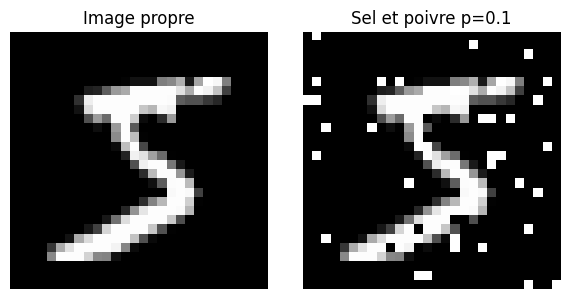

In [27]:
# Création du train set avec bruit sel et poivre


amount_train = 0.10

X_train_sp_flat = add_salt_and_pepper_noise(
    X_train_flat,
    amount=amount_train,
    seed=123
)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(X_train_flat[0].reshape(28, 28), cmap="gray")
plt.title("Image propre")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train_sp_flat[0].reshape(28, 28), cmap="gray")
plt.title(f"Sel et poivre p={amount_train}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Entraînement du MLP2 sur bruit sel et poivre

A1_sp, b1_sp, A2_sp, b2_sp, A3_sp, b3_sp, loss_history_sp = train_mlp_2_hidden(
    X_train_sp_flat,
    Y_train,
    input_dim=784,
    hidden_dim1=512,
    hidden_dim2=128,
    num_classes=10,
    learning_rate=0.2,
    epochs=350
)

In [29]:
# Test du modèle sel et poivre sur images propres

y_pred_sp_clean = predict_2_hidden(
    X_test_flat,
    A1_sp, b1_sp,
    A2_sp, b2_sp,
    A3_sp, b3_sp
)

acc_sp_clean = accuracy(y_test, y_pred_sp_clean)

print("Accuracy du MLP2 entraîné sur sel et poivre et testé sur images propres :", acc_sp_clean)

Accuracy du MLP2 entraîné sur sel et poivre et testé sur images propres : 0.9401


In [30]:
# Sauvegarde du MLP2 entraîné sur bruit sel et poivre


save_results("mlp2_trained_with_salt_pepper_p010_h512_h128.pkl", {
    "amount_train": amount_train,
    "params": {
        "hidden_dim1": 512,
        "hidden_dim2": 128,
        "learning_rate": 0.2,
        "epochs": 350
    },
    "A1": A1_sp,
    "b1": b1_sp,
    "A2": A2_sp,
    "b2": b2_sp,
    "A3": A3_sp,
    "b3": b3_sp,
    "loss_history": loss_history_sp,
    "accuracy_clean_test": acc_sp_clean
})

In [31]:
# Comparaison des trois modèles sur bruit sel et poivre


params_clean = best_mlp2_clean["best_parameters"]

amounts_test = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30]

results_sp_3models = []

for amount in amounts_test:
    X_test_sp_flat = add_salt_and_pepper_noise(
        X_test_flat,
        amount=amount,
        seed=42
    )

    # Modèle entraîné sur images propres
    y_pred_clean = predict_2_hidden(
        X_test_sp_flat,
        params_clean["A1"],
        params_clean["b1"],
        params_clean["A2"],
        params_clean["b2"],
        params_clean["A3"],
        params_clean["b3"]
    )
    acc_clean = accuracy(y_test, y_pred_clean)

    # Modèle entraîné avec bruit gaussien
    y_pred_gaussian = predict_2_hidden(
        X_test_sp_flat,
        A1_noisy, b1_noisy,
        A2_noisy, b2_noisy,
        A3_noisy, b3_noisy
    )
    acc_gaussian = accuracy(y_test, y_pred_gaussian)

    # Modèle entraîné avec bruit sel et poivre
    y_pred_sp = predict_2_hidden(
        X_test_sp_flat,
        A1_sp, b1_sp,
        A2_sp, b2_sp,
        A3_sp, b3_sp
    )
    acc_sp = accuracy(y_test, y_pred_sp)

    results_sp_3models.append({
        "proportion_pixels_modifies": amount,
        "MLP2 propre": acc_clean,
        "MLP2 bruit gaussien": acc_gaussian,
        "MLP2 sel et poivre": acc_sp
    })

df_sp_3models = pd.DataFrame(results_sp_3models)
df_sp_3models

,proportion_pixels_modifies,MLP2 propre,MLP2 bruit gaussien,MLP2 sel et poivre
0,0.00,0.9516,0.9374,0.9401
1,0.02,0.9439,0.9344,0.9360
2,0.05,0.9365,0.9300,0.9320
3,0.10,0.9111,0.9186,0.9238
4,0.20,0.7936,0.8778,0.8884
5,0.30,0.6240,0.7907,0.8126


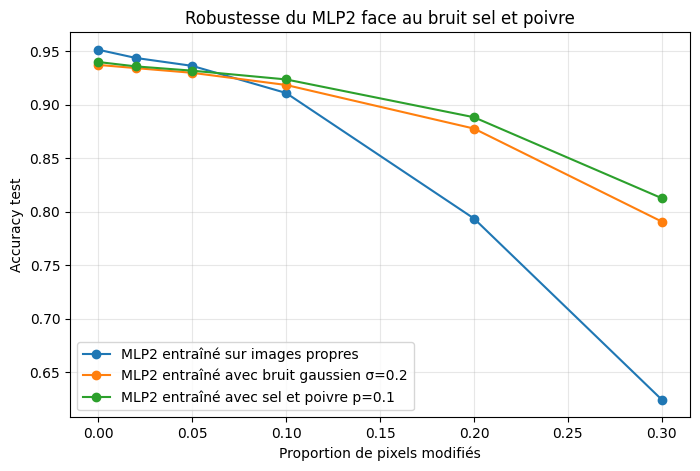

In [32]:
# Graphique comparaison sur bruit sel et poivre


plt.figure(figsize=(8, 5))

plt.plot(
    df_sp_3models["proportion_pixels_modifies"],
    df_sp_3models["MLP2 propre"],
    marker="o",
    label="MLP2 entraîné sur images propres"
)

plt.plot(
    df_sp_3models["proportion_pixels_modifies"],
    df_sp_3models["MLP2 bruit gaussien"],
    marker="o",
    label=f"MLP2 entraîné avec bruit gaussien σ={sigma_train}"
)

plt.plot(
    df_sp_3models["proportion_pixels_modifies"],
    df_sp_3models["MLP2 sel et poivre"],
    marker="o",
    label=f"MLP2 entraîné avec sel et poivre p={amount_train}"
)

plt.xlabel("Proportion de pixels modifiés")
plt.ylabel("Accuracy test")
plt.title("Robustesse du MLP2 face au bruit sel et poivre")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
# Comparaison des trois modèles sur bruit gaussien


params_clean = best_mlp2_clean["best_parameters"]

sigmas_test = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]

results_gaussian_3models = []

for sigma in sigmas_test:
    X_test_gaussian_flat = add_gaussian_noise(
        X_test_flat,
        sigma=sigma,
        seed=42
    )

    # Modèle entraîné sur images propres
    y_pred_clean = predict_2_hidden(
        X_test_gaussian_flat,
        params_clean["A1"],
        params_clean["b1"],
        params_clean["A2"],
        params_clean["b2"],
        params_clean["A3"],
        params_clean["b3"]
    )
    acc_clean = accuracy(y_test, y_pred_clean)

    # Modèle entraîné avec bruit gaussien
    y_pred_gaussian = predict_2_hidden(
        X_test_gaussian_flat,
        A1_noisy, b1_noisy,
        A2_noisy, b2_noisy,
        A3_noisy, b3_noisy
    )
    acc_gaussian = accuracy(y_test, y_pred_gaussian)

    # Modèle entraîné avec bruit sel et poivre
    y_pred_sp = predict_2_hidden(
        X_test_gaussian_flat,
        A1_sp, b1_sp,
        A2_sp, b2_sp,
        A3_sp, b3_sp
    )
    acc_sp = accuracy(y_test, y_pred_sp)

    results_gaussian_3models.append({
        "sigma": sigma,
        "MLP2 propre": acc_clean,
        "MLP2 bruit gaussien": acc_gaussian,
        "MLP2 sel et poivre": acc_sp
    })

df_gaussian_3models = pd.DataFrame(results_gaussian_3models)
df_gaussian_3models

,sigma,MLP2 propre,MLP2 bruit gaussien,MLP2 sel et poivre
0,0.00,0.9516,0.9374,0.9401
1,0.05,0.9498,0.9378,0.9391
2,0.10,0.9442,0.9368,0.9388
3,0.20,0.9173,0.9299,0.9309
4,0.30,0.8185,0.9110,0.9111
5,0.40,0.6759,0.8556,0.8595


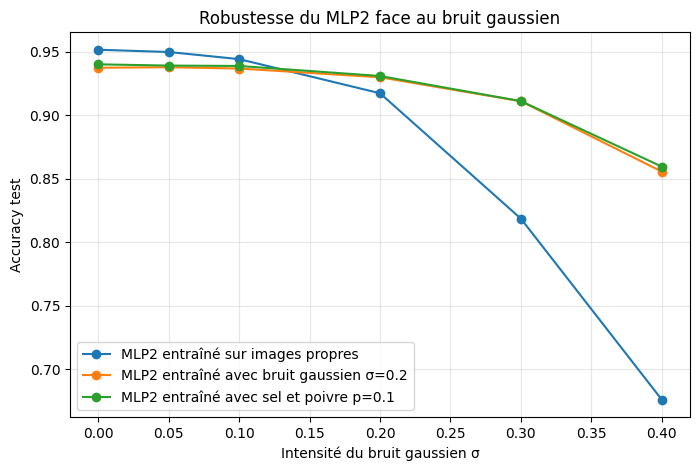

In [34]:
# Graphique comparaison sur bruit gaussien


plt.figure(figsize=(8, 5))

plt.plot(
    df_gaussian_3models["sigma"],
    df_gaussian_3models["MLP2 propre"],
    marker="o",
    label="MLP2 entraîné sur images propres"
)

plt.plot(
    df_gaussian_3models["sigma"],
    df_gaussian_3models["MLP2 bruit gaussien"],
    marker="o",
    label=f"MLP2 entraîné avec bruit gaussien σ={sigma_train}"
)

plt.plot(
    df_gaussian_3models["sigma"],
    df_gaussian_3models["MLP2 sel et poivre"],
    marker="o",
    label=f"MLP2 entraîné avec sel et poivre p={amount_train}"
)

plt.xlabel("Intensité du bruit gaussien σ")
plt.ylabel("Accuracy test")
plt.title("Robustesse du MLP2 face au bruit gaussien")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Entraînement avec data augmentation

Après avoir testé séparément le bruit gaussien et le bruit sel et poivre, nous avons voulu aller plus loin en créant un modèle entraîné sur plusieurs types de perturbations. L'idée est de faire de la data augmentation : on ajoute au jeu d'entraînement des versions légèrement modifiées des images originales afin d'obtenir un modèle plus robuste.

In [35]:
from scipy.ndimage import rotate, shift
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Fonction de data augmentation


def augment_mnist_images(X_images, seed=None):
    """
    Crée une version augmentée des images MNIST.

    Transformations possibles :
    - bruit gaussien léger
    - bruit sel et poivre léger
    - petite rotation
    - petit décalage
    """
    rng = np.random.default_rng(seed)
    X_aug = np.empty_like(X_images)

    for i in range(X_images.shape[0]):
        img = X_images[i].copy()

        # Choix aléatoire d'une transformation
        transform = rng.choice(["gaussian", "salt_pepper", "rotation", "shift"])

        if transform == "gaussian":
            sigma = rng.uniform(0.05, 0.15)
            img = add_gaussian_noise(img, sigma=sigma, seed=None)

        elif transform == "salt_pepper":
            amount = rng.uniform(0.02, 0.08)
            img = add_salt_and_pepper_noise(img, amount=amount, seed=None)

        elif transform == "rotation":
            angle = rng.uniform(-15, 15)
            img = rotate(img, angle=angle, reshape=False, mode="constant", cval=0.0)

        elif transform == "shift":
            shift_x = rng.integers(-2, 3)
            shift_y = rng.integers(-2, 3)
            img = shift(img, shift=(shift_x, shift_y), mode="constant", cval=0.0)

        img = np.clip(img, 0.0, 1.0)
        X_aug[i] = img

    return X_aug

In [37]:
# Création du dataset augmenté

X_train_aug_images = augment_mnist_images(X_train, seed=123)

# On concatène les images propres et les images augmentées
X_train_data_aug = np.concatenate([X_train, X_train_aug_images], axis=0)
y_train_data_aug = np.concatenate([y_train, y_train], axis=0)

# Aplatissement
X_train_data_aug_flat = X_train_data_aug.reshape(X_train_data_aug.shape[0], 28 * 28)

# Labels one-hot
Y_train_data_aug = one_hot_encode(y_train_data_aug, num_classes=10)

print("X_train_data_aug_flat :", X_train_data_aug_flat.shape)
print("Y_train_data_aug :", Y_train_data_aug.shape)

X_train_data_aug_flat : (120000, 784)
Y_train_data_aug : (120000, 10)


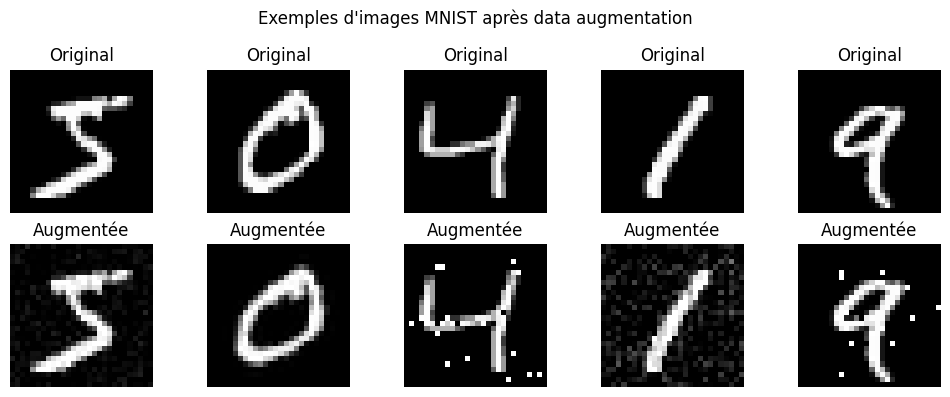

In [38]:
# Visualisation d'exemples de data augmentation


idxs = [0, 1, 2, 3, 4]

plt.figure(figsize=(10, 4))

for i, idx in enumerate(idxs):
    plt.subplot(2, len(idxs), i + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, len(idxs), len(idxs) + i + 1)
    plt.imshow(X_train_aug_images[idx], cmap="gray")
    plt.title("Augmentée")
    plt.axis("off")

plt.suptitle("Exemples d'images MNIST après data augmentation")
plt.tight_layout()
plt.show()

In [39]:
# Entraînement du MLP2 avec data augmentation


A1_aug, b1_aug, A2_aug, b2_aug, A3_aug, b3_aug, loss_history_aug = train_mlp_2_hidden(
    X_train_data_aug_flat,
    Y_train_data_aug,
    input_dim=784,
    hidden_dim1=512,
    hidden_dim2=128,
    num_classes=10,
    learning_rate=0.2,
    epochs=350
)

In [40]:
# Test du modèle data augmentation sur images propres


y_pred_aug_clean = predict_2_hidden(
    X_test_flat,
    A1_aug, b1_aug,
    A2_aug, b2_aug,
    A3_aug, b3_aug
)

acc_aug_clean = accuracy(y_test, y_pred_aug_clean)

print("Accuracy du MLP2 avec data augmentation sur images propres :", acc_aug_clean)

Accuracy du MLP2 avec data augmentation sur images propres : 0.9552


In [41]:
save_results("mlp2_data_augmentation_h512_h128.pkl", {
    "params": {
        "hidden_dim1": 512,
        "hidden_dim2": 128,
        "learning_rate": 0.2,
        "epochs": 350
    },
    "A1": A1_aug,
    "b1": b1_aug,
    "A2": A2_aug,
    "b2": b2_aug,
    "A3": A3_aug,
    "b3": b3_aug,
    "loss_history": loss_history_aug,
    "accuracy_clean_test": acc_aug_clean
})

In [42]:
# =========================
# Comparaison des quatre modèles sur bruit gaussien
# =========================

params_clean = best_mlp2_clean["best_parameters"]
sigmas_test = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]

results_gaussian_4models = []

for sigma in sigmas_test:
    X_test_gaussian_flat = add_gaussian_noise(
        X_test_flat,
        sigma=sigma,
        seed=42
    )

    acc_clean = accuracy(y_test, predict_2_hidden(
        X_test_gaussian_flat,
        params_clean["A1"], params_clean["b1"],
        params_clean["A2"], params_clean["b2"],
        params_clean["A3"], params_clean["b3"]
    ))

    acc_gaussian = accuracy(y_test, predict_2_hidden(
        X_test_gaussian_flat,
        A1_noisy, b1_noisy,
        A2_noisy, b2_noisy,
        A3_noisy, b3_noisy
    ))

    acc_sp = accuracy(y_test, predict_2_hidden(
        X_test_gaussian_flat,
        A1_sp, b1_sp,
        A2_sp, b2_sp,
        A3_sp, b3_sp
    ))

    acc_aug = accuracy(y_test, predict_2_hidden(
        X_test_gaussian_flat,
        A1_aug, b1_aug,
        A2_aug, b2_aug,
        A3_aug, b3_aug
    ))

    results_gaussian_4models.append({
        "sigma": sigma,
        "MLP2 propre": acc_clean,
        "MLP2 bruit gaussien": acc_gaussian,
        "MLP2 sel et poivre": acc_sp,
        "MLP2 data augmentation": acc_aug
    })

df_gaussian_4models = pd.DataFrame(results_gaussian_4models)
df_gaussian_4models

,sigma,MLP2 propre,MLP2 bruit gaussien,MLP2 sel et poivre,MLP2 data augmentation
0,0.00,0.9516,0.9374,0.9401,0.9552
1,0.05,0.9498,0.9378,0.9391,0.9540
2,0.10,0.9442,0.9368,0.9388,0.9514
3,0.20,0.9173,0.9299,0.9309,0.9401
4,0.30,0.8185,0.9110,0.9111,0.8876
5,0.40,0.6759,0.8556,0.8595,0.7781


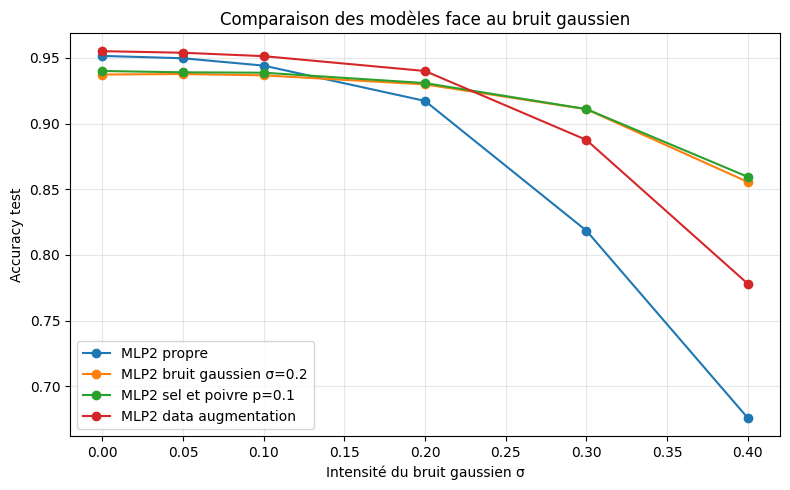

In [44]:
# Graphique comparaison sur bruit gaussien


plt.figure(figsize=(8, 5))

plt.plot(
    df_gaussian_4models["sigma"],
    df_gaussian_4models["MLP2 propre"],
    marker="o",
    label="MLP2 propre"
)

plt.plot(
    df_gaussian_4models["sigma"],
    df_gaussian_4models["MLP2 bruit gaussien"],
    marker="o",
    label=f"MLP2 bruit gaussien σ={sigma_train}"
)

plt.plot(
    df_gaussian_4models["sigma"],
    df_gaussian_4models["MLP2 sel et poivre"],
    marker="o",
    label=f"MLP2 sel et poivre p={amount_train}"
)

plt.plot(
    df_gaussian_4models["sigma"],
    df_gaussian_4models["MLP2 data augmentation"],
    marker="o",
    label="MLP2 data augmentation"
)

plt.xlabel("Intensité du bruit gaussien σ")
plt.ylabel("Accuracy test")
plt.title("Comparaison des modèles face au bruit gaussien")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# Comparaison des quatre modèles sur bruit sel et poivre


amounts_test = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30]

results_sp_4models = []

for amount in amounts_test:
    X_test_sp_flat = add_salt_and_pepper_noise(
        X_test_flat,
        amount=amount,
        seed=42
    )

    acc_clean = accuracy(y_test, predict_2_hidden(
        X_test_sp_flat,
        params_clean["A1"], params_clean["b1"],
        params_clean["A2"], params_clean["b2"],
        params_clean["A3"], params_clean["b3"]
    ))

    acc_gaussian = accuracy(y_test, predict_2_hidden(
        X_test_sp_flat,
        A1_noisy, b1_noisy,
        A2_noisy, b2_noisy,
        A3_noisy, b3_noisy
    ))

    acc_sp = accuracy(y_test, predict_2_hidden(
        X_test_sp_flat,
        A1_sp, b1_sp,
        A2_sp, b2_sp,
        A3_sp, b3_sp
    ))

    acc_aug = accuracy(y_test, predict_2_hidden(
        X_test_sp_flat,
        A1_aug, b1_aug,
        A2_aug, b2_aug,
        A3_aug, b3_aug
    ))

    results_sp_4models.append({
        "proportion_pixels_modifies": amount,
        "MLP2 propre": acc_clean,
        "MLP2 bruit gaussien": acc_gaussian,
        "MLP2 sel et poivre": acc_sp,
        "MLP2 data augmentation": acc_aug
    })

df_sp_4models = pd.DataFrame(results_sp_4models)
df_sp_4models

,proportion_pixels_modifies,MLP2 propre,MLP2 bruit gaussien,MLP2 sel et poivre,MLP2 data augmentation
0,0.00,0.9516,0.9374,0.9401,0.9552
1,0.02,0.9439,0.9344,0.9360,0.9498
2,0.05,0.9365,0.9300,0.9320,0.9422
3,0.10,0.9111,0.9186,0.9238,0.9234
4,0.20,0.7936,0.8778,0.8884,0.8527
5,0.30,0.6240,0.7907,0.8126,0.7211


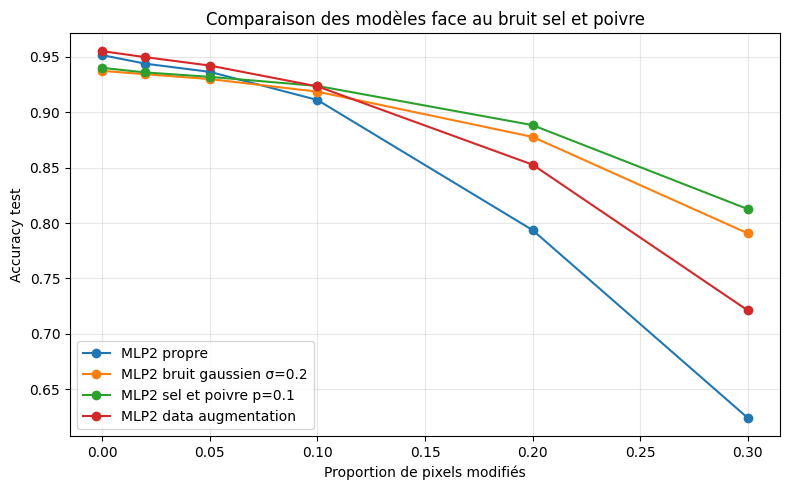

In [46]:
# Graphique comparaison sur bruit sel et poivre


plt.figure(figsize=(8, 5))

plt.plot(
    df_sp_4models["proportion_pixels_modifies"],
    df_sp_4models["MLP2 propre"],
    marker="o",
    label="MLP2 propre"
)

plt.plot(
    df_sp_4models["proportion_pixels_modifies"],
    df_sp_4models["MLP2 bruit gaussien"],
    marker="o",
    label=f"MLP2 bruit gaussien σ={sigma_train}"
)

plt.plot(
    df_sp_4models["proportion_pixels_modifies"],
    df_sp_4models["MLP2 sel et poivre"],
    marker="o",
    label=f"MLP2 sel et poivre p={amount_train}"
)

plt.plot(
    df_sp_4models["proportion_pixels_modifies"],
    df_sp_4models["MLP2 data augmentation"],
    marker="o",
    label="MLP2 data augmentation"
)

plt.xlabel("Proportion de pixels modifiés")
plt.ylabel("Accuracy test")
plt.title("Comparaison des modèles face au bruit sel et poivre")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# =========================
# Comparaison des 4 modèles sur images propres
# =========================

params_clean = best_mlp2_clean["best_parameters"]

# Modèle entraîné sur images propres
y_pred_clean = predict_2_hidden(
    X_test_flat,
    params_clean["A1"], params_clean["b1"],
    params_clean["A2"], params_clean["b2"],
    params_clean["A3"], params_clean["b3"]
)
acc_clean = accuracy(y_test, y_pred_clean)

# Modèle entraîné avec bruit gaussien
y_pred_gaussian = predict_2_hidden(
    X_test_flat,
    A1_noisy, b1_noisy,
    A2_noisy, b2_noisy,
    A3_noisy, b3_noisy
)
acc_gaussian = accuracy(y_test, y_pred_gaussian)

# Modèle entraîné avec bruit sel et poivre
y_pred_sp = predict_2_hidden(
    X_test_flat,
    A1_sp, b1_sp,
    A2_sp, b2_sp,
    A3_sp, b3_sp
)
acc_sp = accuracy(y_test, y_pred_sp)

# Modèle entraîné avec data augmentation
y_pred_aug = predict_2_hidden(
    X_test_flat,
    A1_aug, b1_aug,
    A2_aug, b2_aug,
    A3_aug, b3_aug
)
acc_aug = accuracy(y_test, y_pred_aug)

df_clean_comparison = pd.DataFrame({
    "Modèle": [
        "MLP2 propre",
        "MLP2 bruit gaussien",
        "MLP2 sel et poivre",
        "MLP2 data augmentation"
    ],
    "Accuracy sur images propres": [
        acc_clean,
        acc_gaussian,
        acc_sp,
        acc_aug
    ]
})

df_clean_comparison

,Modèle,Accuracy sur images propres
0,MLP2 propre,0.9516
1,MLP2 bruit gaussien,0.9374
2,MLP2 sel et poivre,0.9401
3,MLP2 data augmentation,0.9552


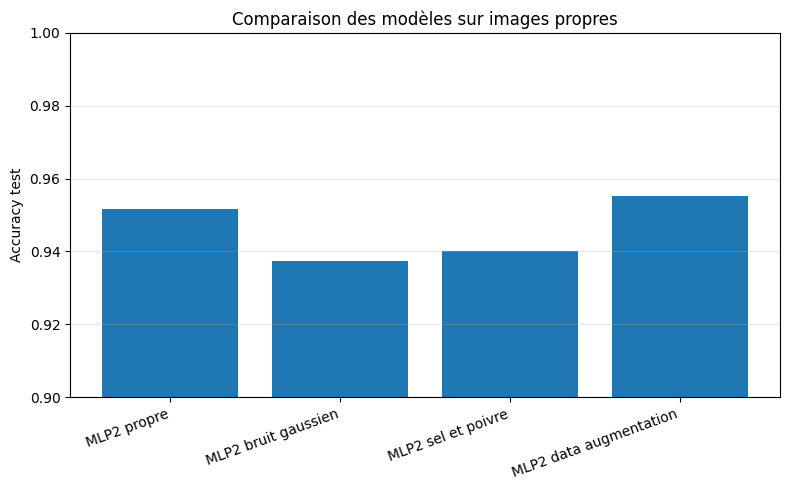

In [48]:
# =========================
# Graphique comparaison sur images propres
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    df_clean_comparison["Modèle"],
    df_clean_comparison["Accuracy sur images propres"]
)

plt.ylabel("Accuracy test")
plt.title("Comparaison des modèles sur images propres")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.90, 1.00)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()